# Sanity Check
Sanity check the `map_converter.ipynb`. Sometimes, the centerline generated is not great, such as what you see for `Spielberg_map`. In these cases, you can increase the interpolation interval in `map_converter.ipynb`, and then clean manually.

Then, you can use this book to sanity check again the points.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from PIL import Image
import os
import pandas as pd
from scipy.ndimage import gaussian_filter1d

In [2]:
MAP_NAME = 'berlin'

In [3]:
if os.path.exists(f"maps/{MAP_NAME}.png"):
    map_img_path = f"maps/{MAP_NAME}.png"
elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
    map_img_path = f"maps/{MAP_NAME}.pgm"
else:
    raise Exception("Map not found!")

map_yaml_path = f"maps/{MAP_NAME}.yaml"
map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM))
map_img = map_img.astype(np.float64)

# load map yaml
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        print(ex)

# calculate map parameters
orig_x = origin[0]
orig_y = origin[1]

In [4]:
track_data = pd.read_csv(f"inputs/tracks/{MAP_NAME}.csv")
x = track_data["# x_m"].to_numpy(dtype=float)
y = track_data["y_m"].to_numpy(dtype=float)
wr = track_data["w_tr_right_m"].to_numpy(dtype=float)
wl = track_data["w_tr_left_m"].to_numpy(dtype=float)
x -= orig_x
y -= orig_y
x /= map_resolution
y /= map_resolution
wr /= map_resolution
wl /= map_resolution

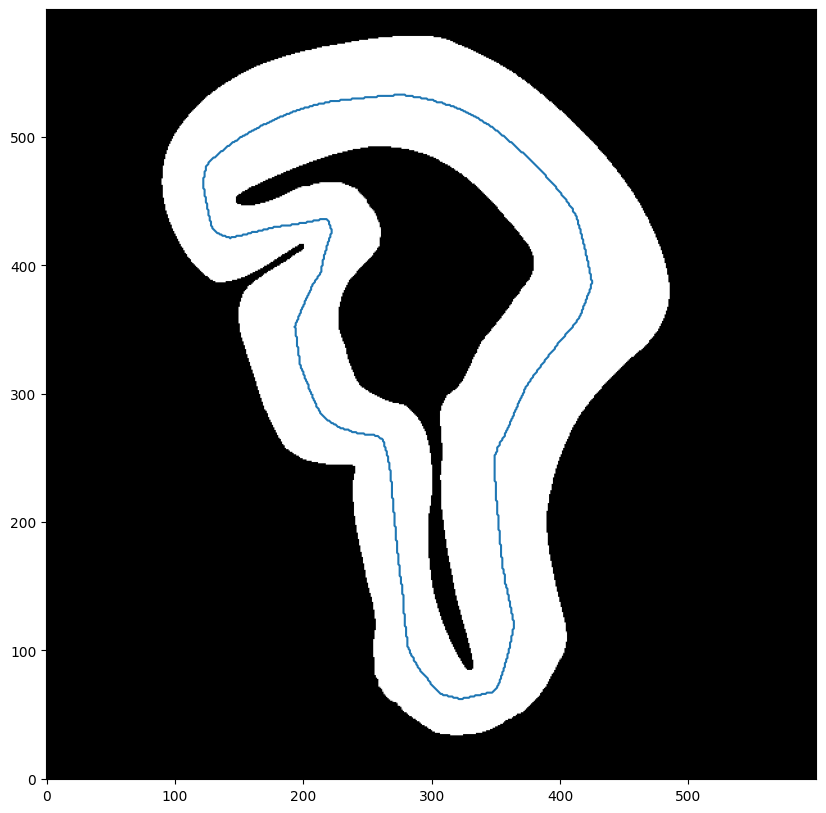

In [5]:
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap="gray", origin="lower")
plt.plot(x,y)

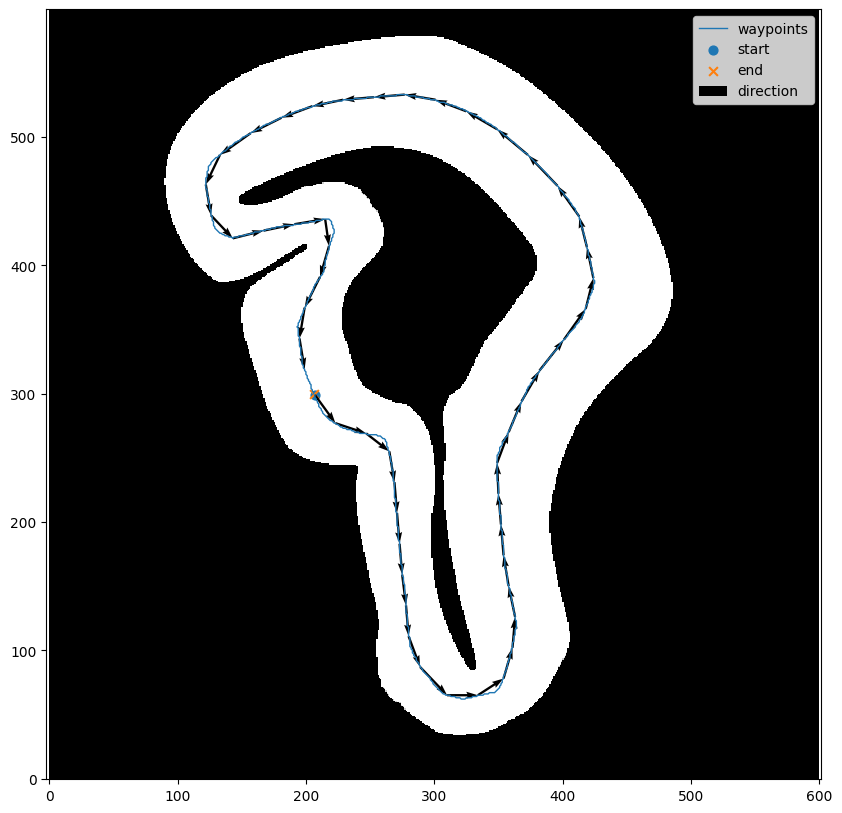

In [9]:
plt.figure(figsize=(10, 10))
plt.imshow(map_img, origin='lower', cmap='gray', interpolation='none')
# Plot the full ordered path
plt.plot(x, y, linewidth=1.0, label='waypoints')
# Mark start and end
plt.scatter(x[0], y[0], s=40, marker='o', label='start')
plt.scatter(x[-1], y[-1], s=40, marker='x', label='end')
# Draw sparse direction arrows
pts = np.column_stack((x, y))
step = max(1, len(pts)) // 50
arrow_pts = pts[::step]
arrow_vecs = np.diff(arrow_pts, axis=0)
plt.quiver(
    arrow_pts[:-1, 0],
    arrow_pts[:-1, 1],
    arrow_vecs[:, 0],
    arrow_vecs[:, 1],
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.003,
    label='direction'
)
plt.axis('equal')
plt.legend()
plt.show()

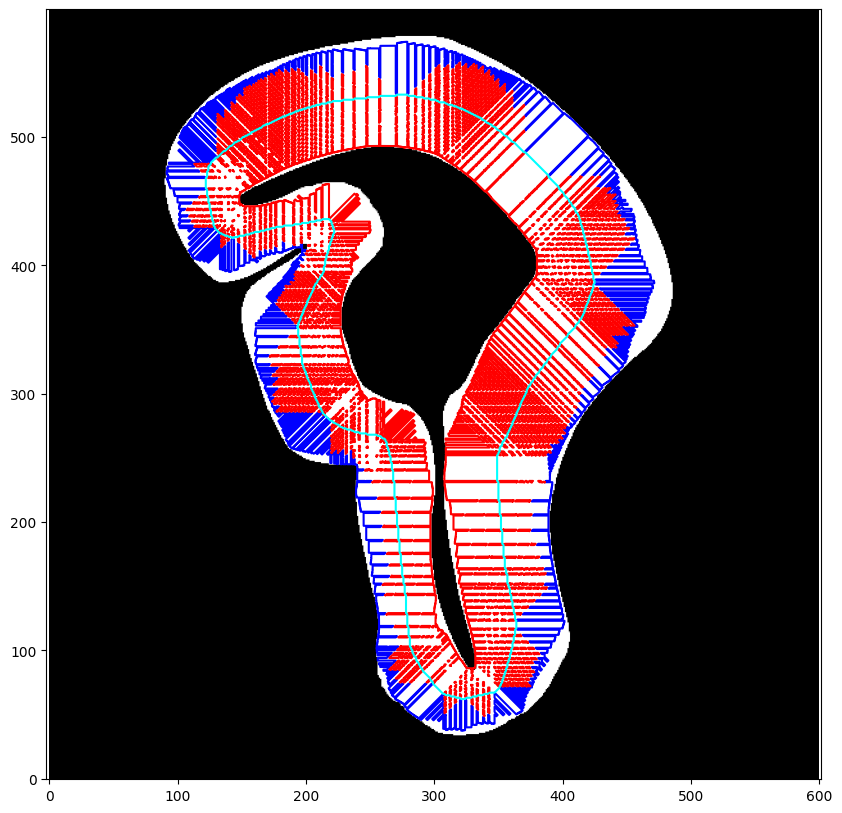

In [6]:
from shapely import Polygon, unary_union

def unit_left_normal(a, b):
    v = b - a
    norm = np.linalg.norm(v)
    if norm < 1e-12:
        return None
    v = v / norm
    return np.array([-v[1], v[0]])
points = np.column_stack((x, y))
polys = []
n = len(points)
for i in range(n):
    a = points[i]
    b = points[(i+1)%n]
    wl_seg = 0.5 * (wl[i] + wl[(i+1)%n])
    wr_seg = 0.5 * (wr[i] + wr[(i+1)%n])
    normal = unit_left_normal(a, b)
    if normal is None:
        continue
    a_left = a + wl_seg * normal
    b_left = b + wl_seg * normal
    a_right = a - wr_seg * normal
    b_right = b - wr_seg * normal
    quad = Polygon([a_left, b_left, b_right, a_right])
    if not quad.is_empty and quad.is_valid:
        polys.append(quad)
track_geom = unary_union(polys)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(map_img, cmap="gray", origin="lower")

if track_geom is not None:
    if track_geom.geom_type == "Polygon":
        outer = np.array(track_geom.exterior.coords)
        ax.plot(outer[:, 0], outer[:, 1], color="blue")

        for hole in track_geom.interiors:
            hole_xy = np.array(hole.coords)
            ax.plot(hole_xy[:, 0], hole_xy[:, 1], color="red")

    elif track_geom.geom_type == "MultiPolygon":
        for poly in track_geom.geoms:
            outer = np.array(poly.exterior.coords)
            ax.plot(outer[:, 0], outer[:, 1], color="blue")
            for hole in poly.interiors:
                hole_xy = np.array(hole.coords)
                ax.plot(hole_xy[:, 0], hole_xy[:, 1], color="red")

ax.plot(points[:, 0], points[:, 1], color="cyan")
ax.axis("equal")
plt.show()

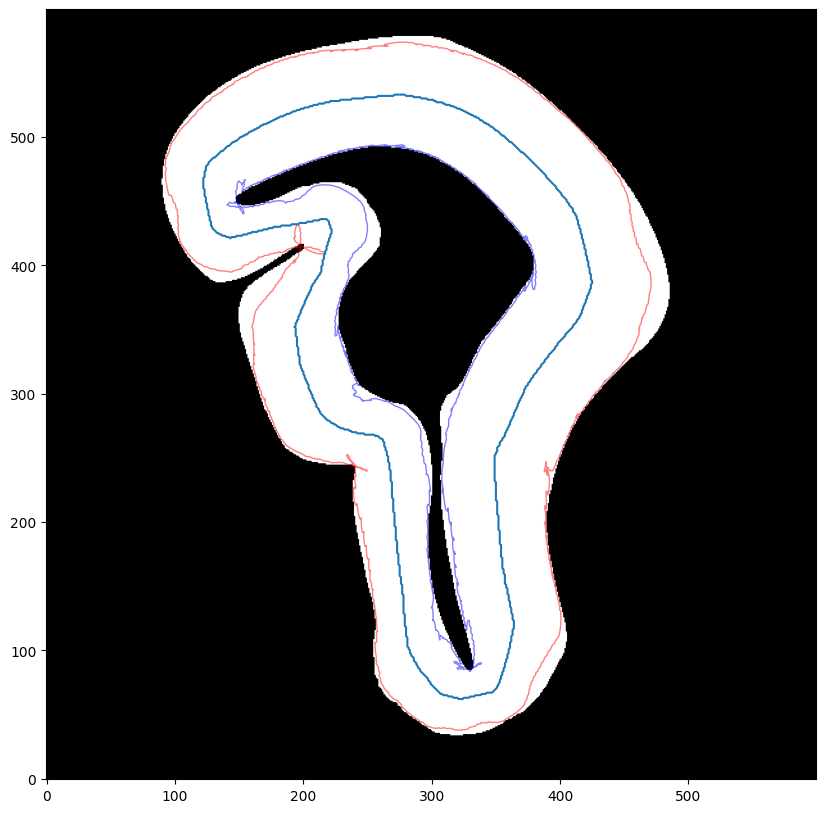

In [7]:
# Compare track widths (guassian filter)
x_s = gaussian_filter1d(x, sigma=2.0, mode='wrap')
y_s = gaussian_filter1d(y, sigma=2.0, mode='wrap')
points = np.column_stack((x_s, y_s))
points_closed = np.vstack((points, points[0,:]))
tangents = points_closed[1:] - points_closed[:-1]
norms = np.linalg.norm(tangents, axis=1, keepdims=True)
norms[norms == 0] = 1.0
tangents /= norms
# Changes from row, col to x, y
normals = np.column_stack((-tangents[:,1], tangents[:, 0]))
left_boundary = points + normals * wl[:, None]
right_boundary = points - normals * wr[:, None]

plt.figure(figsize=(10,10))
# plt.plot(x, y, '--')
plt.plot(left_boundary[:,0], left_boundary[:,1], color='blue', linewidth=1, alpha=0.5)
plt.plot(right_boundary[:,0], right_boundary[:,1], color='red', linewidth=1, alpha=0.5)
plt.imshow(map_img, cmap="gray", origin="lower")
plt.plot(x,y)
plt.show()